# Lung Cancer Knowledge Graph
This folder contains the 'LC.nt' graph, a KG in RDF format that represents information about many patients suffering from Lung Cancer.
This notebook performs data exploration and analysis to gain insights about the information represented in this graph.
## Schema discovery
I want to figure out which entities exist and how they are connected to each other before anything else. Usually I would have this information beforehand, but let's assume I don't. 

In [44]:
from rdflib import Graph
from rdflib import Namespace

# Initialize an empty graph
g = Graph()

# Parse the .nt file
g.parse('LC.nt', format='nt')

# To avoid strings overhead, I'll bind the URIs usinf rdflib
EX = Namespace("http://example.org/lungCancer/entity/")
RDF = Namespace("http://www.w3.org/1999/02/22-rdf-syntax-ns#")

g.bind("ex", EX)
g.bind("rdf", RDF)

print(f"G graph loaded with {len(g)} triples.")

G graph loaded with 5269 triples.


To extract resources from the graph I can query the graph using SPARQL with the `Graph.query()` method, resulting in a `Result` object instance. I'll use it to discover the different types of predicates in the KG. Iterating over the `Result` yields `ResultRow` instances.

In [45]:
# Discover the predicates within the graph.
query = """
    SELECT DISTINCT ?p
    WHERE {
        ?s ?p ?o .
    }
"""

# Query the graph
answer = g.query(query)

print(f"There are {len(answer)} different predicates:")
for row in answer:
    print(f"{row.p}")

There are 9 different predicates:
http://example.org/lungCancer/entity/hasStage
http://example.org/lungCancer/entity/hasBiomarker
http://example.org/lungCancer/entity/treatmentType
http://example.org/lungCancer/entity/patientDrug
http://example.org/lungCancer/entity/hasSmokingHabit
http://example.org/lungCancer/entity/hasAgeCategory
http://www.w3.org/1999/02/22-rdf-syntax-ns#type
http://example.org/lungCancer/entity/hasGender
http://example.org/lungCancer/entity/hasRelapse_Progression


Even though I have bounded the prefixes, iterating through the results still yields the data as full `URIRef` objects. To get the clean, short `ex:Patient_123` string, I need to ask the graph to format the output using the `Graph.qname()` method. I'll discover the unique subject types and # of entities in the graph:

In [46]:
# Discover unique entities, i.e., count the occurrences of each rdf:type
query = """
    SELECT ?type (COUNT(?s) AS ?count)
    WHERE {
        # There is no need to define rdf: prefix since its binded to a namespace in previous steps
        ?s rdf:type ?type .
    }
    GROUP BY ?type
    ORDER BY DESC(?count)
"""

answer = g.query(query)
print(f"There are {len(answer)} entity types:")
for row in answer:
    if row['type']:
        print(f"Type: {g.qname(row['type'])} | Count: {row['count']}")

There are 1 entity types:
Type: ex:Patient | Count: 319


In [ ]:
# Query to sample one object for each of the 9 predicates
sample_query = """
SELECT ?p (SAMPLE(?o) AS ?example_object)
WHERE {
    ?s ?p ?o .
}
GROUP BY ?p
"""

print("Predicate -> Example Object")
print("-" * 40)
for row in g.query(sample_query):
    # Check if it's a URI or a Literal
    from rdflib import URIRef, Literal
    
    obj_type = "URI (Node)" if isinstance(row.example_object, URIRef) else "Literal (Value)"
    print(f"Predicate: {row.p}")
    print(f"Type:      {obj_type}")
    print(f"Example:   {row.example_object}\n")

This KG only represents entities of type `ex:Patient` and 9 different predicates that relate these patients to different attributes. 

>**Since the only `rdf:type` is `ex:Patient`, does this mean that other nodes are not defined as classes? e.g., in the pattern `{ ex:Patient ex:hasGender ?gender .}`, `?gender` is composed only by literals?**
> 
>Yes. Because `ex:Patient` is the only `rdf:type` in the entire graph, it means the graph is highly "patient-centric" or "flat." A predicate can point to another entity (a URI), but in the triples it is not explicitly typed as a class (e.g., `(ex:Patient ex:hasGender ex:Male .)`, but `(ex:Male rdf:type ex:Gender .)` is not defined in the KG).

Next, I'll check the different values of objects in the graph.

In [ ]:
from rdflib import URIRef, Literal

# Query to sample one object for each of the 9 predicates
sample_query = """
    SELECT ?p (SAMPLE(?o) AS ?example_object)
    WHERE {
        ?s ?p ?o .
    }
    GROUP BY ?p
"""

print("Predicate -> Example Object")
for row in g.query(sample_query):
    
    # Check if it's a URI or a Literal
    obj_type = "URI (Node)" if isinstance(row.example_object, URIRef) else "Literal (Value)"
    print(f"Predicate: {row.p} |Type:   {obj_type} |Example:    {row.example_object}")

## Data Analysis
To perform data analysis, I'll flatten a portion to the graph to pandas. I'll retrieve the data about patients related to smoking habits and their genders.

In [47]:
import pandas as pd

patient_query = """
    SELECT ?patient ?smokeHabit ?gender
    WHERE {
        # Find all patients
        ?patient rdf:type ex:Patient .

        # Use OPTIONAL so we don't drop patients missing hasSmokingHabit or hasGender
        OPTIONAL {?patient ex:hasSmokingHabit ?smokeHabit .}
        OPTIONAL {?patient ex:hasGender ?gender .}
    }
"""

answer = g.query(patient_query)
print(f"Query resulted in {len(answer)} results. Bear in mind that graph nodes can have "
      "multiple values for each predicate, so these do not refer necessarily to 319 unique entities.")

Query resulted in 319 results. Bear in mind that graph nodes can have multiple values for each predicate, so these do not refer necessarily to 319 unique entities.


In [48]:
# Convert rdflib query results into a list of dictionaries, then to a DataFrame
data = []
for row in answer:
    data.append({
        "Patient ID": g.qname(row['patient']),
        "Smoking Habit": g.qname(row['smokeHabit']) if row['smokeHabit'] else None,
        "Gender": g.qname(row['gender']) if row['gender'] else None
    })

df = pd.DataFrame(data)

# Check the number of unique patients
print(f"Rows: {len(df)} | Unique patients: {df['Patient ID'].nunique()}")

Rows: 319 | Unique patients: 319


>Would be naive to assume that there cannot be more than one value for the `ex:hasSmokingHabit` predicate for each patient of type `ex:Patient`? It wouldn't bee too complicated to check how many different subjects each predicate has for each subject.

Let's see how many patients have a smoking habit and how that relates to gender.

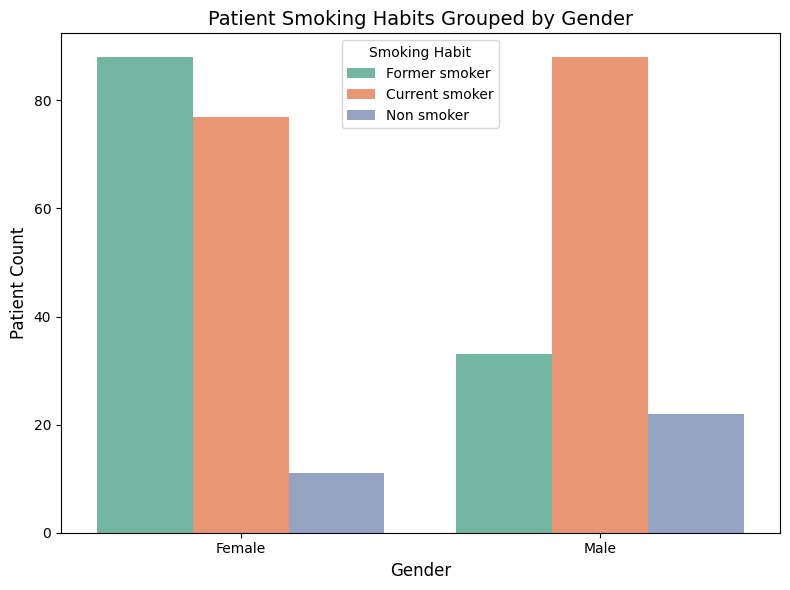

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

from plot_utils import clean_df_for_plotting

plotting_df = clean_df_for_plotting(df, ['Smoking Habit', 'Gender'])

# Create the plot defining input
plt.figure(figsize=(8, 6))
sns.countplot(data=plotting_df, x='Gender', hue='Smoking Habit', palette='Set2')

# Add labels and title
plt.title('Patient Smoking Habits Grouped by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)

plt.tight_layout()
plt.show()
